# Figure 6 Nearest neighbor connectivity and the spatial orientation of morphologies explain network complexity
#### Results of the test for outgoing connectivity applied to the data of Peng et al. 2024, human model described in Barros-Zulaica et al., 2026 and a rat model described in Markram et al., 2015.
#### Black: overall connection probability in the data; 
#### Green:conditioned on the nearest neighbor within a patch-sample being connected. 
#### Grey and light green indicate corresponding results for a configuration-model, i.e., a control that captures the effect of long-tailed degree distributions. 
#### Dashed lines show the mean and shaded area the standard error of the mean over 1000 instances. 

In [9]:
import numpy, pandas
import conntility

from scipy.spatial.distance import pdist, squareform
from scipy import sparse
from scipy.stats import percentileofscore
from matplotlib import pyplot as plt

In [10]:
fn_root = "/Users/natali_obi_account/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix/"

# for Peng
#fn = fn_root+"peng_et_al_human_multi_patch_grp.h5"
#prefix = "peng_et_al"

# for human model
fn = fn_root+"human_model_multi_patch_grp_peng-like.h5"
prefix = "human_model"

# for rat model
#fn = fn_root+"rat_model_multi_patch_grp_peng-like.h5"
#prefix = "rat_model"

G = conntility.ConnectivityGroup.from_h5(fn)

# Peng
#coords = ["coordinate_1", "coordinate_2", "coordinate_3"]

# Human and rat model
coords = ["slice_x", "slice_y"]

In [11]:
def configuration_model(mat, vert, direction="efferent"):
    if direction == "afferent":
        return configuration_model(mat.transpose(), vert).transpose()
    assert direction == "efferent"
    rows = []
    for i in range(mat.shape[0]):
        rows.append(numpy.random.choice(
            numpy.setdiff1d(numpy.arange(mat.shape[1]), [i]),
            mat[i].nnz, replace=False
        ))
    data = numpy.ones(mat.nnz)
    indices = numpy.hstack(rows)
    indptr = numpy.cumsum([0] + list(map(len, rows)))
    ret = sparse.csr_matrix((data, indices, indptr), shape=mat.shape)
    assert ret.nnz == mat.nnz
    return ret
    

In [12]:
def analysis_func2(m, v, direction="efferent"):
    m = numpy.array(m.todense().astype(bool))
    d = squareform(pdist(v[coords]))
    numpy.fill_diagonal(d, numpy.inf)
    nn_idx = numpy.argmin(d, axis=0)
    if direction == "efferent":
        m_nn = m[:, nn_idx]
    elif direction == "afferent":
        m_nn = m[nn_idx]
    else: raise ValueError()
    return pandas.DataFrame(
        {
            "is_connected": m.flatten(),
            "nn_connected": m_nn.flatten(),
            "distance": d.flatten()
        }
    )

analysis_recipe = {
    "analyses": {
        "morphology_effect2":{
            "source": analysis_func2,
            "kwargs": {"direction": "efferent"},
            "output": "DataFrame",
            "decorators":[
                {
                    "name": "control_by_randomization",
                    "args":[configuration_model],
                    "kwargs": {"only_mean": False, "n_randomizations": 1000, "direction": "efferent"}
                }
            ]
        }
    }
}
full_res = G.analyze(analysis_recipe=analysis_recipe)
res = full_res["morphology_effect2"]

res = pandas.concat(res.values, axis=0, keys=res.index)
res = res.loc[~numpy.isinf(res["distance"])].copy()
res

is_connected  nn_connected    distance
index Control    Instance                                           
0     data       0        1          False         False   74.214764
                          2           True         False  109.632236
                          3          False         False  140.542511
                          4           True         False  168.396584
                          5          False         False  181.726581
...                                    ...           ...         ...
230   randomized 999      58          True         False  216.665909
                          59          True         False   67.449759
                          60         False         False   47.984740
                          61         False          True  137.444938
                          62         False          True  117.896102

[9125116 rows x 3 columns]

In [13]:
dbins = numpy.arange(0, 240 + 35, 35)
bin_names = [f"{int(a)}-{int(b)} um" for a, b in zip(dbins[:-1], dbins[1:])] + [f"> {int(dbins[-1])} um"]
bin_names = numpy.array(bin_names)
for col in ["distance"]:
    outcol = "binned_" + col
    res[outcol] = bin_names[numpy.digitize(res[col], bins=dbins) - 1]


/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_7707/3656689087.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(bin_names, rotation="vertical", fontsize=8)
/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_7707/3656689087.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_7707/3656689087.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)


Text(0, 0.5, 'P')

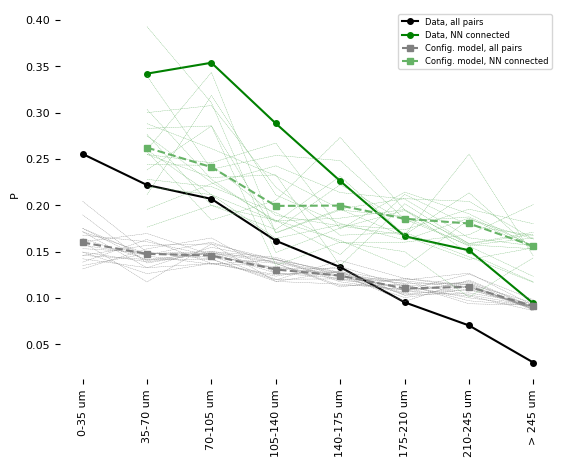

In [14]:
min_smpl = 25

con_probs_nn = res.groupby(["nn_connected", "Control", "Instance", "binned_distance"])["is_connected"].mean()
smpl_count_nn = res.groupby(["nn_connected", "Control", "Instance", "binned_distance"])["is_connected"].count()
con_probs_nn[smpl_count_nn < min_smpl] = numpy.nan
con_probs_nn = con_probs_nn.unstack("binned_distance").loc[True, bin_names]

con_probs_all = res.groupby(["Control", "Instance", "binned_distance"])["is_connected"].mean()
smpl_count_all = res.groupby(["Control", "Instance", "binned_distance"])["is_connected"].count()
con_probs_all[smpl_count_all < min_smpl] = numpy.nan
con_probs_all = con_probs_all.unstack("binned_distance")[bin_names]

fig = plt.figure()#figsize=(3.5, 2.0))
ax = fig.gca()

ax.plot(con_probs_all.loc["data"].transpose(), color="black", marker="o", ms=4, label="Data, all pairs")
ax.plot(con_probs_nn.loc["data"].transpose(), color="green", marker="o", ms=4, label="Data, NN connected")

rnd = numpy.random.choice(len(con_probs_nn.loc["randomized"]), 20, replace=False)
ax.plot(con_probs_all.loc["randomized"].transpose()[rnd], color="grey", ls="--", lw=0.25)
ax.plot(con_probs_all.loc["randomized"].mean(), color="grey", ls="--", lw=1.5, marker="s", ms=4, label="Config. model, all pairs")
ax.plot(con_probs_nn.loc["randomized"].transpose()[rnd], color=[0.4, 0.7, 0.4], ls="--", lw=0.25)
ax.plot(con_probs_nn.loc["randomized"].mean(), color=[0.4, 0.7, 0.4], ls="--", lw=1.5, marker="s", ms=4, label="Config. model, NN connected")


plt.legend(fontsize=6)
ax.set_frame_on(False)
_ = ax.set_xticklabels(bin_names, rotation="vertical", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
ax.set_ylabel("P", fontsize=8)

#fig.savefig(f"{prefix}_1d_morph_effect1.svg")

/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_7707/3793955118.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(bin_names, rotation="vertical", fontsize=8)
/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_7707/3793955118.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_7707/3793955118.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)


Text(0, 0.5, 'P')

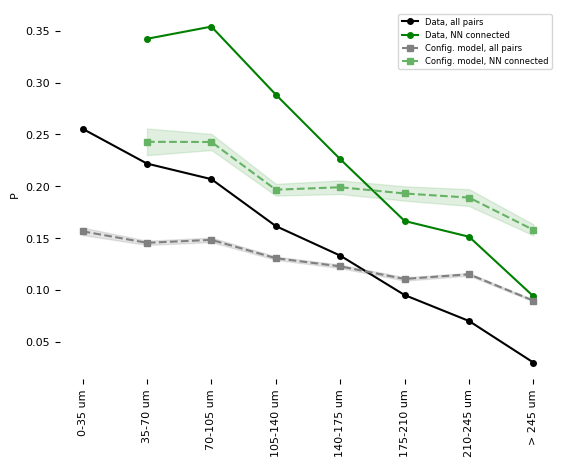

In [15]:
min_smpl = 25

con_probs_nn = res.groupby(["nn_connected", "Control", "Instance", "binned_distance"])["is_connected"].mean()
smpl_count_nn = res.groupby(["nn_connected", "Control", "Instance", "binned_distance"])["is_connected"].count()
con_probs_nn[smpl_count_nn < min_smpl] = numpy.nan
con_probs_nn = con_probs_nn.unstack("binned_distance").loc[True, bin_names]

con_probs_all = res.groupby(["Control", "Instance", "binned_distance"])["is_connected"].mean()
smpl_count_all = res.groupby(["Control", "Instance", "binned_distance"])["is_connected"].count()
con_probs_all[smpl_count_all < min_smpl] = numpy.nan
con_probs_all = con_probs_all.unstack("binned_distance")[bin_names]

fig = plt.figure()#figsize=(3.5, 2.0))
ax = fig.gca()

ax.plot(con_probs_all.loc["data"].transpose(), color="black", marker="o", ms=4, label="Data, all pairs")
ax.plot(con_probs_nn.loc["data"].transpose(), color="green", marker="o", ms=4, label="Data, NN connected")

#rnd = numpy.random.choice(len(con_probs_nn.loc["randomized"]), 20, replace=False)
#ax.plot(con_probs_all.loc["randomized"].transpose()[rnd], color="grey", ls="--", lw=0.25)

rnd = numpy.random.choice(len(con_probs_nn.loc["randomized"]), 20, replace=False)
x = numpy.arange(con_probs_all.loc["randomized"].shape[1])  # assumes columns are x-axis

# --- GRAY group (all pairs) set stderr for shadowing---
gray_data = con_probs_all.loc["randomized"].transpose()[rnd]
gray_mean = gray_data.mean(axis=1)
#gray_min = gray_data.min(axis=1)
#gray_max = gray_data.max(axis=1)
gray_data_stderr = gray_data.std(axis=1)/numpy.sqrt(20)

ax.fill_between(x, gray_mean-gray_data_stderr, gray_mean+gray_data_stderr, color="grey", alpha=0.2)   # shadow band
ax.plot(x, gray_mean, color="grey", ls="--", lw=1.5, marker="s", ms=4,
         label="Config. model, all pairs")

# --- GREEN group (NN connected) set min and max for shadowing---
green_data = con_probs_nn.loc["randomized"].transpose()[rnd]
green_mean = green_data.mean(axis=1)
#green_min = green_data.min(axis=1)
#green_max = green_data.max(axis=1)
green_data_stderr = green_data.std(axis=1)/numpy.sqrt(20)


ax.fill_between(x, green_mean-green_data_stderr, green_mean+green_data_stderr, color=[0.4, 0.7, 0.4], alpha=0.2)  # min–max shadow
ax.plot(x, green_mean, color=[0.4, 0.7, 0.4], ls="--", lw=1.5, marker="s", ms=4,
         label="Config. model, NN connected")


#ax.plot(con_probs_all.loc["randomized"].mean(), color="grey", ls="--", lw=1.5, marker="s", ms=4, label="Config. model, all pairs")

#ax.plot(con_probs_nn.loc["randomized"].transpose()[rnd], color=[0.4, 0.7, 0.4], ls="--", lw=0.25)

#ax.plot(con_probs_nn.loc["randomized"].mean(), color=[0.4, 0.7, 0.4], ls="--", lw=1.5, marker="s", ms=4, label="Config. model, NN connected")


plt.legend(fontsize=6)
ax.set_frame_on(False)
_ = ax.set_xticklabels(bin_names, rotation="vertical", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
ax.set_ylabel("P", fontsize=8)

#fig.savefig(f"{prefix}_1d_morph_effect1.svg")

/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_7707/4011311237.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_7707/4011311237.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_7707/4011311237.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_7707/4011311237.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca

[Text(0.125, 0, '0.125'),
 Text(0.15, 0, '0.150'),
 Text(0.175, 0, '0.175'),
 Text(0.2, 0, '0.200'),
 Text(0.225, 0, '0.225'),
 Text(0.25, 0, '0.250')]

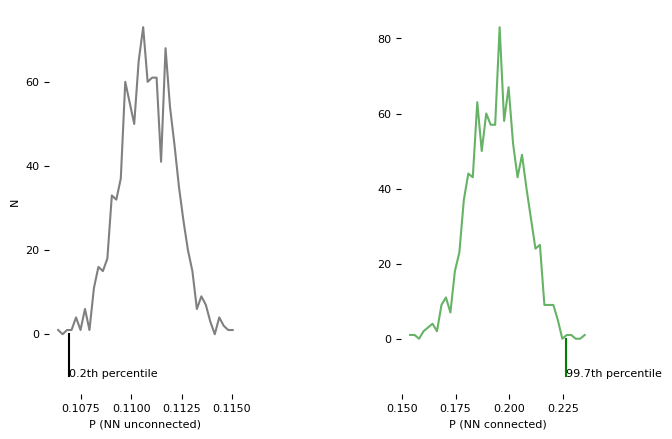

In [16]:
mean_vals = res.groupby(["Control", "Instance", "nn_connected"])["is_connected"].mean().unstack("nn_connected")

fig = plt.figure()#figsize=(3, 1.5))

ax = fig.add_axes([0.1, 0.1, 0.3, 0.8])

bins = numpy.linspace(mean_vals.loc["randomized", False].min(),
                      mean_vals.loc["randomized", False].max(), 41)

h = numpy.histogram(mean_vals.loc["randomized", False], bins=bins)[0]
ax.plot(bins[:-1], h, color="grey")
v = mean_vals.loc["data", False].values[0]
perc = percentileofscore(mean_vals.loc["randomized", False], v)
ax.plot([v, v], [-10, 0], color="black")
ax.text(v, -10, f"{perc}th percentile", fontsize=8)
ax.set_frame_on(False)
ax.set_xlabel("P (NN unconnected)", fontsize=8)
ax.set_ylabel("N", fontsize=8)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)

ax = fig.add_axes([0.65, 0.1, 0.3, 0.8])
bins = numpy.linspace(0.17, 0.25, 41)
bins = numpy.linspace(mean_vals.loc["randomized", True].min(),
                      mean_vals.loc["randomized", True].max(), 41)

h = numpy.histogram(mean_vals.loc["randomized", True], bins=bins)[0]
ax.plot(bins[:-1], h, color=[0.4, 0.7, 0.4])
v = mean_vals.loc["data", True]
perc = percentileofscore(mean_vals.loc["randomized", True], v[0])
ax.plot([v[0], v[0]], [-10, 0], color="green")
ax.text(v[0], -10, f"{perc}th percentile", fontsize=8)
ax.set_frame_on(False)
ax.set_xlabel("P (NN connected)", fontsize=8)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)

#fig.savefig(f"{prefix}_1d_morph_effect2.svg")
